# PROJETO – ANÁLISE EXPLORATÓRIA DE DADOS

## Introdução

Este projeto tem como objetivo realizar uma análise exploratória de dados de vendas de uma loja de varejo, utilizando Python e bibliotecas voltadas para análise de dados e visualização gráfica.

Os dados analisados contêm informações sobre vendas diárias, categorias de produtos, preços, quantidades vendidas, descontos aplicados e características dos clientes, como idade e renda.

A proposta do projeto consiste em responder perguntas estratégicas levantadas pela equipe de marketing da empresa, buscando identificar padrões de consumo, sazonalidade de produtos, impacto de promoções e comportamento de diferentes faixas etárias.


---

### Bibliotecas utilizadas

- Pandas
- Matplotlib
- Seaborn

---

### Objetivos da análise

- Identificar categorias mais vendidas;
- Avaliar sazonalidade de produtos;
- Analisar comportamento de consumo por faixa etária;
- Comparar períodos promocionais;
- Avaliar impacto dos descontos nas vendas.

## Preparação dos dados

Nesta etapa foi realizado o carregamento do arquivo CSV, conversão da coluna de datas e criação de colunas auxiliares utilizadas nas análises, como mês, dia da semana e faixa etária.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# carregar arquivo
df = pd.read_csv(
    r"C:\Users\swend\Desktop\pasta projeto analise exploratoria de dados\vendas_supermercado_com_cliente.csv"
)

# converter datas
df["Data"] = pd.to_datetime(df["Data"])

# criar colunas auxiliares
df["Mes"] = df["Data"].dt.month
df["Nome_Mes"] = df["Data"].dt.month_name()
df["Dia_Semana"] = df["Data"].dt.day_name()

# faixa etária
def faixa(idade):
    if 18 <= idade <=35:
        return "Jovem"
    elif 36 <= idade <=59:
        return "Adulto"
    else:
        return "Idoso"

df["Faixa_Etaria"] = df["Idade"].apply(faixa)

df.head()


print(df.head())
print(df.shape)

        Data   Produto          Categoria  Preço  Quantidade  Desconto  \
0 2023-01-01     Maçãs  Alimentos Frescos  16.46          10       0.0   
1 2023-01-01   Bananas  Alimentos Frescos   2.39           4       0.0   
2 2023-01-01  Laranjas  Alimentos Frescos   8.38           5       0.0   
3 2023-01-01   Tomates  Alimentos Frescos   2.03          15       0.0   
4 2023-01-01    Alface  Alimentos Frescos  37.14          14       0.0   

   Total_Venda  Idade    Renda  Mes Nome_Mes Dia_Semana Faixa_Etaria  
0       164.60     49  2715.61    1  January     Sunday       Adulto  
1         9.56     29  2280.15    1  January     Sunday        Jovem  
2        41.90     67  4419.56    1  January     Sunday        Idoso  
3        30.45     29  3809.17    1  January     Sunday        Jovem  
4       519.96     24  1013.42    1  January     Sunday        Jovem  
(20075, 13)


# 1. "Quais foram as categorias produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas"?

## Análise das categorias mais vendidas

Nesta etapa será realizada a identificação das categorias de produtos com maior volume de vendas, além da análise dos meses em que ocorreram os maiores picos de vendas para cada categoria.

In [7]:
## pergunta 01  ##
## Quais categorias foram mais vendidas e em quais meses tiveram pico? ##

categoria_vendas = df.groupby(
    "Categoria"
)["Quantidade"].sum().sort_values(ascending=False)

print(categoria_vendas)


Categoria
Alimentos Frescos              54755
Produtos de Mercearia          21857
Laticínios e Ovos              18602
Produtos de Limpeza            18448
Produtos de Higiene Pessoal    18374
Bebidas                        18206
Pet Shop                       18081
Congelados                     18051
Utilidades Domésticas          14530
Name: Quantidade, dtype: int64


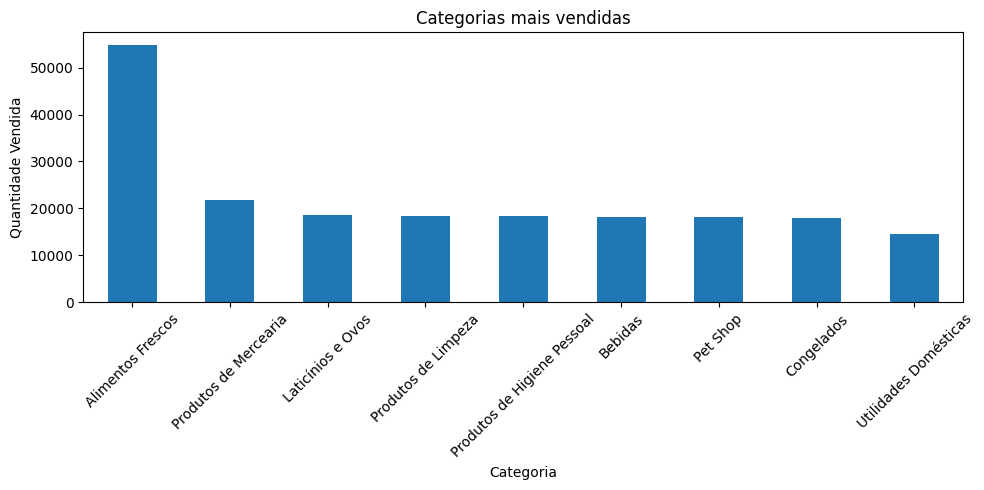

In [ ]:
## Gráfico ## 


plt.figure(figsize=(10,5))

categoria_vendas.plot(kind='bar')

plt.title("Categorias mais vendidas")
plt.xlabel("Categoria")
plt.ylabel("Quantidade Vendida")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [8]:
## Meses de pico ## 

pico = df.groupby(
    ["Categoria","Nome_Mes"]
)["Quantidade"].sum().reset_index()

mes_pico = pico.loc[
    pico.groupby("Categoria")["Quantidade"].idxmax()
]

print(mes_pico)

                      Categoria  Nome_Mes  Quantidade
7             Alimentos Frescos     March        4832
16                      Bebidas   January        1651
34                   Congelados   October        1649
43            Laticínios e Ovos     March        1681
54                     Pet Shop      June        1586
68  Produtos de Higiene Pessoal       May        1641
82          Produtos de Limpeza   October        1650
86        Produtos de Mercearia  December        1950
98        Utilidades Domésticas  December        1308


### Análise dos resultados

A análise das vendas mostrou que a categoria **Alimentos Frescos** foi a mais vendida durante o período analisado, totalizando 54.755 unidades comercializadas, valor significativamente superior às demais categorias. Esse resultado indica uma alta demanda recorrente por produtos perecíveis e de consumo frequente.

Em seguida, destacaram-se as categorias **Produtos de Mercearia** e **Laticínios e Ovos**, demonstrando forte participação nas vendas totais da empresa.

Em relação aos períodos de maior desempenho, observou-se que diferentes categorias apresentaram picos de vendas em meses específicos. A categoria **Alimentos Frescos** teve seu maior volume de vendas no mês de março, enquanto categorias como **Produtos de Mercearia** e **Utilidades Domésticas** apresentaram maiores vendas em dezembro, possivelmente influenciadas pelo aumento do consumo durante as festas de final de ano.

Esses resultados ajudam a identificar padrões sazonais e podem auxiliar a empresa no planejamento de estoque, campanhas promocionais e estratégias de vendas.

# 2. "Qual a média de vendas diárias por categoria de produto"?

## Análise da média de vendas diárias

Nesta etapa será calculada a média de vendas diárias de cada categoria de produto. Essa análise permite identificar quais categorias apresentam maior desempenho médio ao longo do período analisado.

In [ ]:
## pergunta 02 ## 
## Média de vendas diárias por categoria ## 

vendas_dia = df.groupby(
    ["Data","Categoria"]
)["Total_Venda"].sum()

media = vendas_dia.groupby(
    "Categoria"
).mean()

print(media)



Categoria
Alimentos Frescos              3740.573855
Bebidas                        1244.915513
Congelados                     1204.712693
Laticínios e Ovos              1260.165676
Pet Shop                       1206.387844
Produtos de Higiene Pessoal    1205.587619
Produtos de Limpeza            1226.153029
Produtos de Mercearia          1451.105881
Utilidades Domésticas           984.993361
Name: Total_Venda, dtype: float64


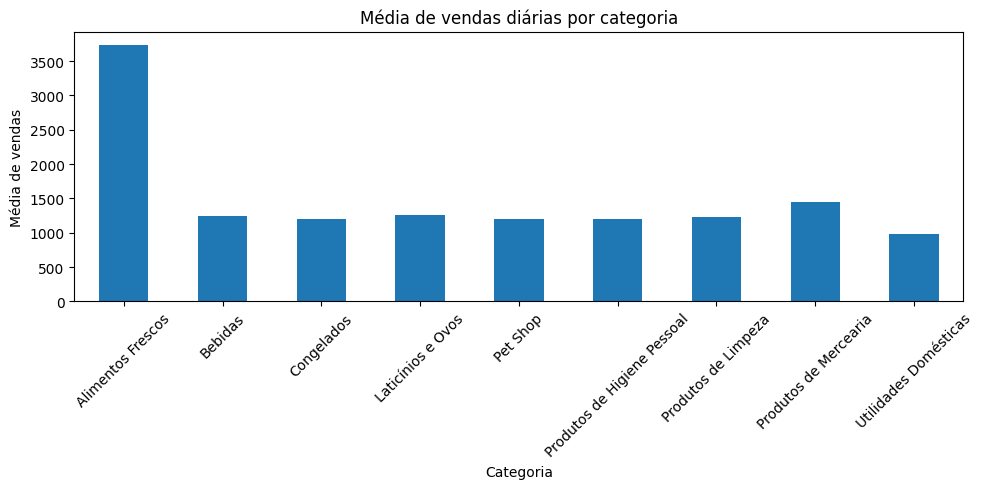

In [ ]:
## Gráfico ## 

plt.figure(figsize=(10,5))

media.plot(kind='bar')

plt.title("Média de vendas diárias por categoria")
plt.xlabel("Categoria")
plt.ylabel("Média de vendas")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Análise dos resultados

A análise da média de vendas diárias mostrou que a categoria **Alimentos Frescos** apresentou o maior desempenho médio entre todas as categorias, alcançando aproximadamente 3.740 em vendas diárias. Esse resultado demonstra que os produtos frescos possuem alta rotatividade e forte demanda contínua ao longo do período analisado.

A categoria **Produtos de Mercearia** também apresentou destaque, com média diária superior às demais categorias secundárias, indicando relevância no faturamento da empresa.

Por outro lado, a categoria **Utilidades Domésticas** apresentou a menor média de vendas diárias, sugerindo menor frequência de compra quando comparada aos produtos de consumo recorrente.

De forma geral, os resultados evidenciam que categorias relacionadas ao consumo cotidiano possuem maior participação nas vendas diárias da empresa.

# 3. "Quais produtos apresentam a maior sazonalidade nas vendas (ex.: frutas e vegetais, sorvetes)"?

## Análise da sazonalidade dos produtos

Nesta etapa será analisada a sazonalidade das vendas dos produtos ao longo dos meses. Para isso, será utilizado o desvio padrão das quantidades vendidas mensalmente, permitindo identificar quais produtos apresentam maior variação nas vendas durante o período analisado.

In [ ]:
## pergunta 3 ##
## Produtos com maior sazonalidade ## 

mensal = df.groupby(
    ["Produto","Mes"]
)["Quantidade"].sum().reset_index()

sazonalidade = mensal.groupby(
    "Produto"
)["Quantidade"].std()

sazonalidade = sazonalidade.sort_values(
    ascending=False
)

print(sazonalidade.head(10))



Produto
Croissants                                         47.615569
Sabão em pó                                        45.707568
Ovos                                               43.228428
Pão integral                                       41.880783
Pratos prontos congelados                          41.314756
Shampoos                                           39.006992
Sabonetes                                          38.979015
Esponjas                                           37.670823
Produtos descartáveis (pratos, copos, talheres)    37.030291
Sucos                                              36.609632
Name: Quantidade, dtype: float64


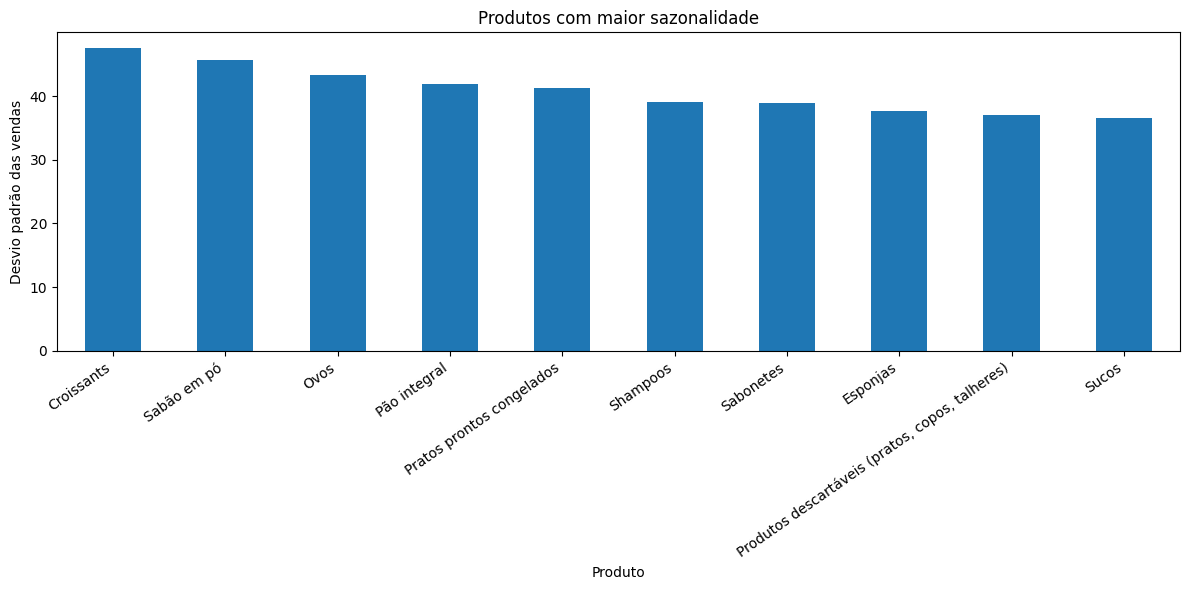

In [ ]:
## Gráfico ## 

plt.figure(figsize=(12,6))

sazonalidade.head(10).plot(kind='bar')

plt.title("Produtos com maior sazonalidade")
plt.xlabel("Produto")
plt.ylabel("Desvio padrão das vendas")

plt.xticks(rotation=35, ha='right')

plt.tight_layout()

plt.show()

### Análise dos resultados

A análise da sazonalidade permitiu identificar os produtos que apresentaram maior variação de vendas ao longo dos meses. O produto **Croissants** apresentou o maior nível de sazonalidade, com desvio padrão de aproximadamente 47,6, indicando forte oscilação de vendas durante o período analisado.

Também se destacaram produtos como **Sabão em pó**, **Ovos** e **Pão integral**, demonstrando comportamento de vendas variável ao longo do ano. Essas oscilações podem estar relacionadas a fatores sazonais, campanhas promocionais, mudanças no comportamento do consumidor ou períodos específicos de maior demanda.

Além disso, produtos como **Pratos prontos congelados**, **Shampoos** e **Sabonetes** também apresentaram níveis relevantes de variação, sugerindo influência de hábitos de consumo específicos em determinados períodos.

A identificação da sazonalidade é importante para auxiliar a empresa no planejamento de estoque, definição de estratégias promocionais e previsão de demanda.

# 4. "Quais as faixas etárias contribuíram mais para as vendas totais? Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso)".

## Análise das vendas por faixa etária

Nesta etapa será analisada a contribuição de cada faixa etária para o total de vendas da empresa. Para isso, os clientes foram classificados em três grupos:

- Jovem: entre 18 e 35 anos;
- Adulto: entre 36 e 59 anos;
- Idoso: acima de 60 anos.

O objetivo é identificar quais grupos possuem maior participação no faturamento total da empresa.

In [ ]:
## pergunta 4  ## 
## Faixas etárias que mais contribuíram ## 

faixa_total = df.groupby(
    "Faixa_Etaria"
)["Total_Venda"].sum().sort_values(ascending=False)

print(
    faixa_total.apply(
        lambda x: f"R$ {x:,.2f}"
    )
)


Faixa_Etaria
Adulto    R$ 2,102,041.77
Jovem     R$ 1,537,183.38
Idoso     R$ 1,297,252.20
Name: Total_Venda, dtype: str


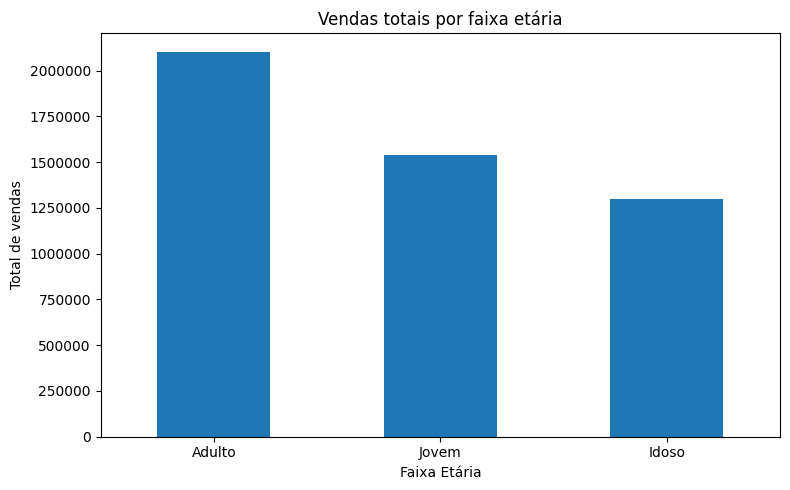

In [ ]:
## Gráfico ## 

plt.figure(figsize=(8,5))

faixa_total.plot(kind='bar')

plt.title("Vendas totais por faixa etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Total de vendas")

plt.xticks(rotation=0)

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

### Análise dos resultados

A análise das vendas por faixa etária mostrou que os clientes classificados como **Adultos** foram os que mais contribuíram para o faturamento total da empresa, ultrapassando o valor de 2 milhões em vendas durante o período analisado.

Em seguida, destacaram-se os clientes da faixa **Jovem**, enquanto o grupo **Idoso** apresentou menor participação relativa nas vendas totais.

Os resultados sugerem que o público adulto representa o principal perfil consumidor da empresa, indicando maior frequência de compras ou maior volume de consumo quando comparado às demais faixas etárias.

Essas informações podem auxiliar a empresa no direcionamento de campanhas de marketing, promoções e estratégias comerciais voltadas ao perfil predominante de clientes.

# 5.  "Qual é a relação entre a idade dos clientes e a categoria de produto mais vendida para cada"? 

## Relação entre faixa etária e categorias de produtos

Nesta etapa será analisada a relação entre as faixas etárias dos clientes e as categorias de produtos mais consumidas por cada grupo.

A análise permitirá identificar padrões de comportamento de consumo entre jovens, adultos e idosos, auxiliando na compreensão do perfil dos clientes da empresa.

In [9]:
## pergunta 5 ## 
## Relação entre idade e categoria mais comprada ## 

idade_categoria = df.groupby(
    ["Faixa_Etaria","Categoria"]
)["Quantidade"].sum()

print(idade_categoria)

Faixa_Etaria  Categoria                  
Adulto        Alimentos Frescos              23212
              Bebidas                         7491
              Congelados                      7499
              Laticínios e Ovos               7875
              Pet Shop                        7989
              Produtos de Higiene Pessoal     7812
              Produtos de Limpeza             7497
              Produtos de Mercearia           9622
              Utilidades Domésticas           6012
Idoso         Alimentos Frescos              14365
              Bebidas                         5034
              Congelados                      4807
              Laticínios e Ovos               4871
              Pet Shop                        4488
              Produtos de Higiene Pessoal     4557
              Produtos de Limpeza             4800
              Produtos de Mercearia           5365
              Utilidades Domésticas           4053
Jovem         Alimentos Frescos         

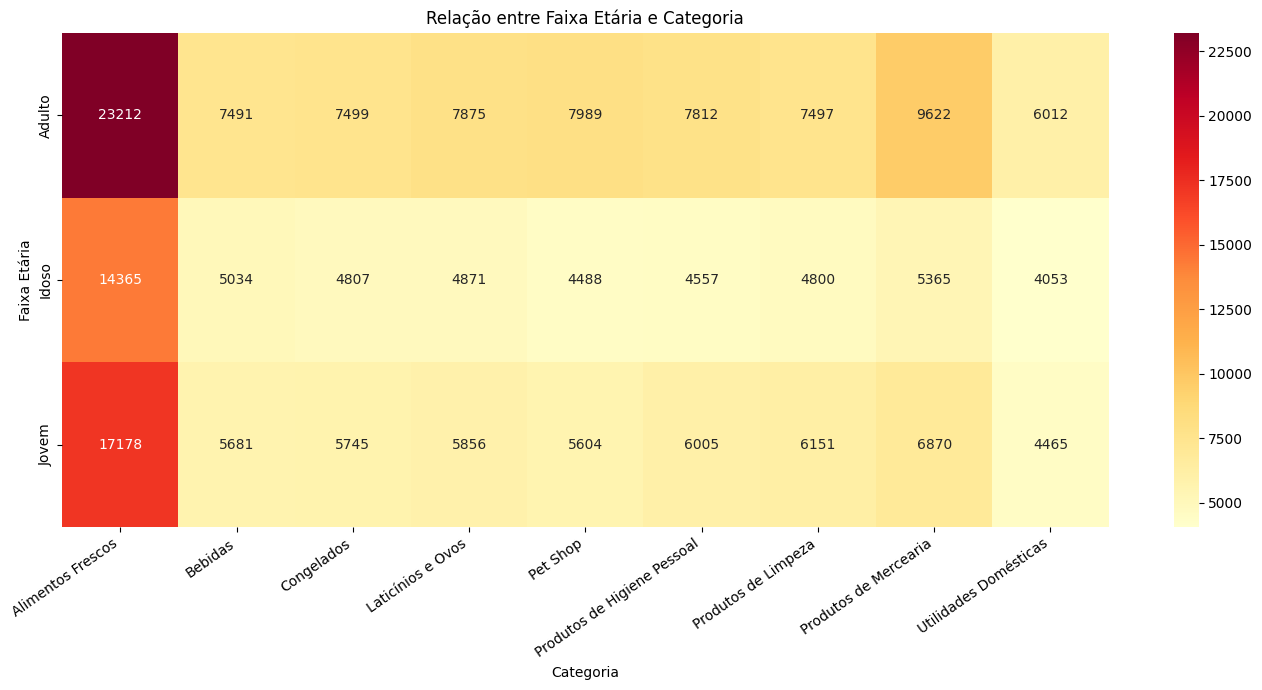

In [ ]:
## Gráfico ##

tabela = idade_categoria.unstack()

plt.figure(figsize=(14,7))

sns.heatmap(
    tabela,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Relação entre Faixa Etária e Categoria")

plt.xlabel("Categoria")
plt.ylabel("Faixa Etária")

plt.xticks(rotation=35, ha='right')

plt.tight_layout()

plt.show()

### Análise dos resultados

A análise da relação entre faixa etária e categorias de produtos demonstrou que a categoria **Alimentos Frescos** apresentou o maior volume de vendas em todas as faixas etárias analisadas.

Os clientes classificados como **Adultos** foram os que mais contribuíram para as vendas em praticamente todas as categorias, com destaque para:

- Alimentos Frescos: 23.212 unidades;
- Produtos de Mercearia: 9.622 unidades;
- Pet Shop: 7.989 unidades.

Os clientes da faixa **Jovem** também apresentaram participação significativa, especialmente em categorias relacionadas ao consumo cotidiano, como Produtos de Limpeza, Produtos de Higiene Pessoal e Produtos de Mercearia.

Já os clientes classificados como **Idosos** apresentaram menor volume total de compras quando comparados aos demais grupos, embora também tenham demonstrado maior concentração de consumo em Alimentos Frescos e Produtos de Mercearia.

Os resultados evidenciam diferenças no comportamento de consumo entre as faixas etárias, permitindo que a empresa desenvolva campanhas promocionais e estratégias de marketing mais direcionadas para cada perfil de cliente.

# 6. "Qual a distribuição das vendas ao longo dos dias da semana"?

## Distribuição das vendas por dia da semana

Nesta etapa será analisado o comportamento das vendas ao longo dos dias da semana, permitindo identificar quais dias apresentam maior volume de vendas e possíveis padrões de consumo dos clientes.

In [ ]:
## pergunta 6 ## 

## Distribuição ao longo da semana ##

dias = df.groupby(
    "Dia_Semana"
)["Total_Venda"].sum()

print(dias)



Dia_Semana
Friday       707290.9067
Monday       695777.3132
Saturday     707984.3710
Sunday       722783.6753
Thursday     706311.1298
Tuesday      686277.9357
Wednesday    710052.0152
Name: Total_Venda, dtype: float64


In [ ]:
# Organizando a ordem correta dos dias #

ordem = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dias = df.groupby(
    "Dia_Semana"
)["Total_Venda"].sum()

dias = dias.reindex(ordem)

print(dias)

Dia_Semana
Monday       695777.3132
Tuesday      686277.9357
Wednesday    710052.0152
Thursday     706311.1298
Friday       707290.9067
Saturday     707984.3710
Sunday       722783.6753
Name: Total_Venda, dtype: float64


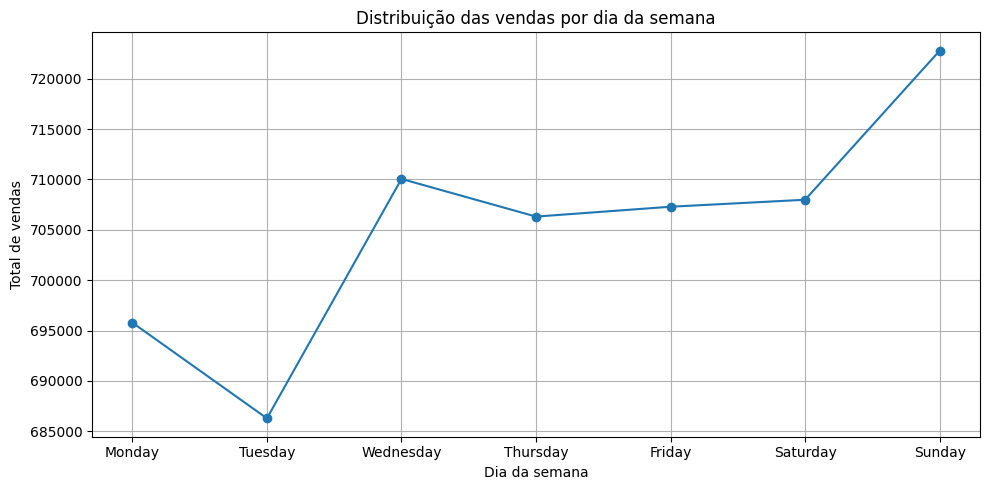

In [ ]:
## Gráfico ## 

plt.figure(figsize=(10,5))

plt.plot(
    dias.index,
    dias.values,
    marker='o'
)

plt.title("Distribuição das vendas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Total de vendas")

plt.ticklabel_format(style='plain', axis='y')

plt.grid(True)

plt.tight_layout()

plt.show()

### Análise dos resultados

A análise da distribuição das vendas ao longo da semana demonstrou que o volume de vendas permaneceu relativamente equilibrado entre os diferentes dias.

O domingo apresentou o maior volume de vendas, ultrapassando 722 mil em faturamento, enquanto a terça-feira registrou o menor desempenho, com aproximadamente 686 mil em vendas.

Apesar dessas diferenças, observa-se que a variação entre os dias da semana não foi muito elevada, indicando estabilidade no comportamento de consumo dos clientes ao longo do período analisado.

Esses resultados sugerem que a empresa mantém fluxo de vendas relativamente constante durante toda a semana, embora finais de semana apresentem leve aumento na movimentação comercial.

# 7. "Como as vendas mensais se comparam antes e durante a Black Friday"?

## Comparação das vendas antes e durante a Black Friday

Nesta etapa será realizada uma comparação entre o volume de vendas antes e durante o período da Black Friday, permitindo identificar o impacto das promoções no desempenho comercial da empresa.

In [ ]:
## pergunta 07 ## 
## Antes e durante Black Friday ## 

black = df[
    (df["Data"] >= "2023-11-24")
    &
    (df["Data"] <= "2023-11-30")
]

antes = df[
    (df["Data"] >= "2023-11-17")
    &
    (df["Data"] < "2023-11-24")
]

print("Antes da Black Friday:")
print(antes["Total_Venda"].sum())

print("\nDurante a Black Friday:")
print(black["Total_Venda"].sum())


Antes da Black Friday:
85870.3449

Durante a Black Friday:
71280.326


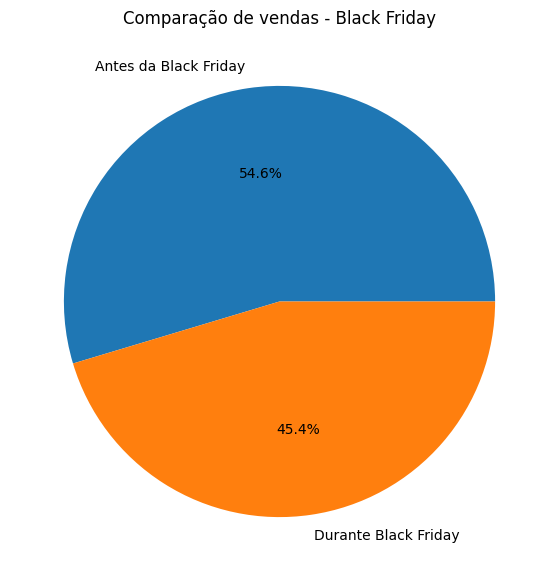

In [ ]:
## Gráfico ## 

comparacao = {
    "Antes da Black Friday":
    antes["Total_Venda"].sum(),

    "Durante Black Friday":
    black["Total_Venda"].sum()
}

plt.figure(figsize=(7,7))

plt.pie(
    comparacao.values(),
    labels=comparacao.keys(),
    autopct='%1.1f%%'
)

plt.title("Comparação de vendas - Black Friday")

plt.show()

### Análise dos resultados

A comparação entre os períodos antes e durante a Black Friday demonstrou que o volume de vendas registrado antes do período promocional foi superior ao observado durante a própria Black Friday.

O período anterior apresentou aproximadamente 85 mil em vendas, enquanto durante a Black Friday o total foi de cerca de 71 mil.

Esse resultado pode indicar que os consumidores anteciparam suas compras antes do período promocional ou que as campanhas de desconto não geraram aumento significativo no faturamento da empresa.

A análise sugere que a empresa pode revisar suas estratégias promocionais para tornar a Black Friday mais atrativa e aumentar o impacto das campanhas comerciais nesse período.

# 8. "Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto"?

## Análise do ticket médio por faixa etária

Nesta etapa será analisado o ticket médio das vendas por faixa etária e sua variação entre diferentes categorias de produtos.

O ticket médio representa o valor médio gasto pelos clientes em suas compras, permitindo identificar padrões de consumo entre os diferentes perfis de consumidores.

In [ ]:
## pergunta 08  ## 
## Ticket médio por faixa etária ##

ticket = df.groupby(
["Faixa_Etaria","Categoria"]
)["Total_Venda"].mean()

print(ticket)

Faixa_Etaria  Categoria                  
Adulto        Alimentos Frescos              253.664059
              Bebidas                        240.421985
              Congelados                     245.670753
              Laticínios e Ovos              249.264281
              Pet Shop                       247.798387
              Produtos de Higiene Pessoal    244.521748
              Produtos de Limpeza            249.264331
              Produtos de Mercearia          242.295457
              Utilidades Domésticas          246.394274
Idoso         Alimentos Frescos              251.970517
              Bebidas                        261.236944
              Congelados                     240.421544
              Laticínios e Ovos              256.349856
              Pet Shop                       234.930971
              Produtos de Higiene Pessoal    240.051339
              Produtos de Limpeza            238.871165
              Produtos de Mercearia          245.313649
      

In [ ]:
ticket_tabela = ticket.unstack()

print(ticket_tabela)

Categoria     Alimentos Frescos     Bebidas  Congelados  Laticínios e Ovos  \
Faixa_Etaria                                                                 
Adulto               253.664059  240.421985  245.670753         249.264281   
Idoso                251.970517  261.236944  240.421544         256.349856   
Jovem                241.413459  249.464292  234.943750         252.191323   

Categoria       Pet Shop  Produtos de Higiene Pessoal  Produtos de Limpeza  \
Faixa_Etaria                                                                 
Adulto        247.798387                   244.521748           249.264331   
Idoso         234.930971                   240.051339           238.871165   
Jovem         237.327133                   237.544760           245.422972   

Categoria     Produtos de Mercearia  Utilidades Domésticas  
Faixa_Etaria                                                
Adulto                   242.295457             246.394274  
Idoso                    245.313649

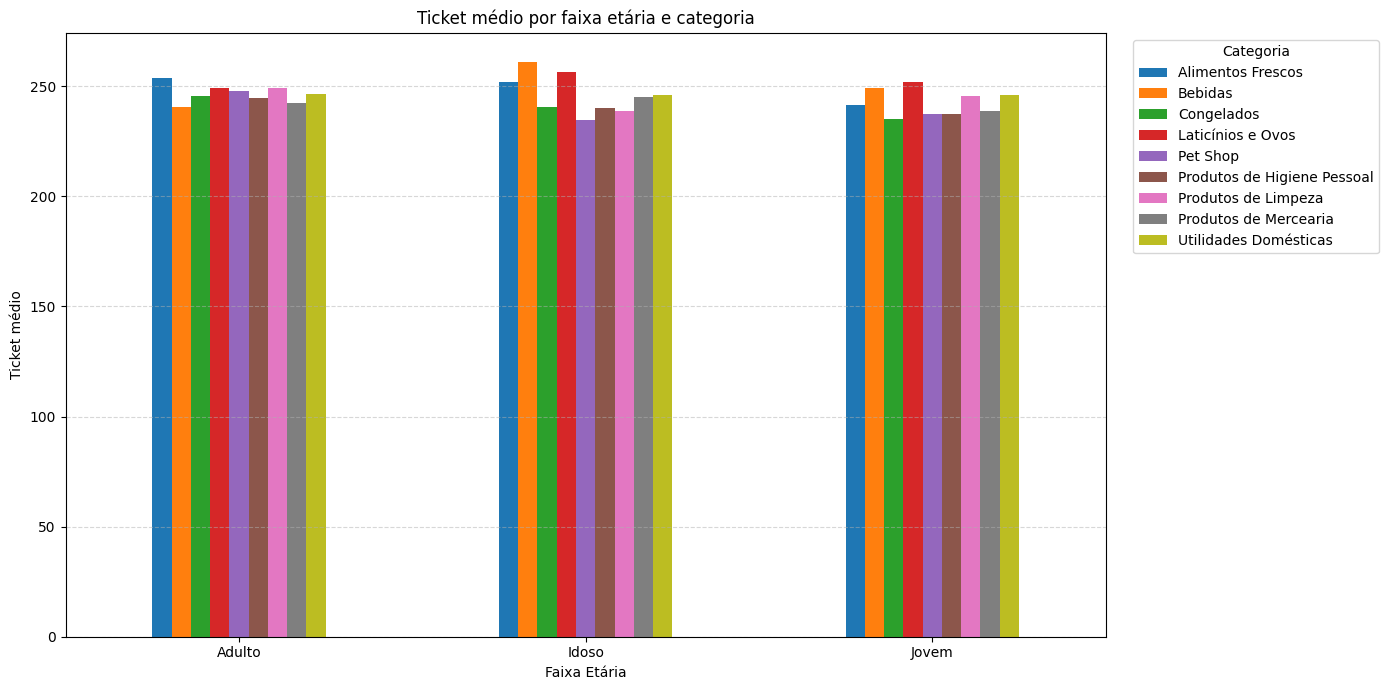

In [ ]:
## Gráfico ## 

ticket_tabela.plot(
    kind='bar',
    figsize=(14,7)
)

plt.title("Ticket médio por faixa etária e categoria")

plt.xlabel("Faixa Etária")
plt.ylabel("Ticket médio")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(
    title="Categoria",
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

### Análise dos resultados

A análise do ticket médio demonstrou diferenças no comportamento de consumo entre as faixas etárias e categorias de produtos.

Os clientes classificados como **Idosos** apresentaram os maiores tickets médios em categorias como:

- Bebidas: aproximadamente 261;
- Laticínios e Ovos: aproximadamente 256.

Os clientes **Adultos** apresentaram comportamento mais equilibrado entre as categorias, mantendo ticket médio relativamente elevado em praticamente todos os segmentos analisados.

Já os clientes **Jovens** apresentaram menores tickets médios em categorias como Congelados e Produtos de Mercearia, embora tenham demonstrado valores elevados em categorias como Laticínios e Ovos.

Os resultados indicam diferenças no padrão de consumo entre os grupos etários, permitindo que a empresa desenvolva estratégias comerciais e campanhas mais direcionadas para cada perfil de cliente.

# 9.  " Comparando a semana da “Black Friday” com a do Natal, qual semana a empresa teve melhores desempenhos em relação à média de vendas"?

## Comparação do desempenho médio de vendas

Nesta etapa será realizada uma comparação entre a média de vendas da semana da Black Friday e da semana do Natal, permitindo identificar qual período sazonal apresentou melhor desempenho comercial para a empresa.

In [ ]:
## pergunta 09 ##
## Semana Black Friday x Natal ## 

black_week = df[
    (df["Data"] >= "2023-11-24")
    &
    (df["Data"] <= "2023-11-30")
]

natal_week = df[
    (df["Data"] >= "2023-12-18")
    &
    (df["Data"] <= "2023-12-24")
]

media_black = black_week["Total_Venda"].mean()
media_natal = natal_week["Total_Venda"].mean()

print("Média Black Friday:")
print(media_black)

print("\nMédia Natal:")
print(media_natal)


Média Black Friday:
185.1437038961039

Média Natal:
225.2317755844156


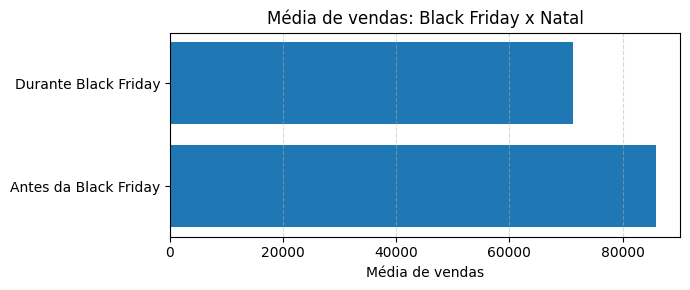

In [ ]:
## Gráfico ##
plt.figure(figsize=(7,3))

plt.barh(
    comparacao.keys(),
    comparacao.values()
)

plt.title("Média de vendas: Black Friday x Natal")

plt.xlabel("Média de vendas")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

### Análise dos resultados

A comparação entre as médias de vendas da semana da Black Friday e da semana do Natal demonstrou que o período natalino apresentou melhor desempenho comercial.

A média de vendas durante a semana da Black Friday foi de aproximadamente 185, enquanto na semana do Natal a média alcançou cerca de 225.

Apesar de a diferença não ser extremamente elevada, observa-se que o Natal apresentou desempenho superior, indicando maior volume médio de compras durante esse período sazonal.

Os resultados sugerem que o Natal possui impacto comercial mais relevante para a empresa quando comparado à Black Friday, podendo representar uma oportunidade importante para investimentos em campanhas promocionais e estratégias de marketing voltadas ao fim de ano.

# 10.Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções?

## Avaliação do impacto dos descontos

Nesta etapa será analisado o impacto das promoções e descontos aplicados sobre as vendas dos produtos.

O objetivo é identificar se os descontos contribuíram para o aumento das vendas e quais produtos apresentaram maior desempenho promocional.

In [ ]:
## pergunta 10 ## 
## qual impacto dos desconto? ## 

# vendas com desconto
com_desconto = df[df["Desconto"] > 0]

# vendas sem desconto
sem_desconto = df[df["Desconto"] == 0]

# total vendido
total_com_desconto = com_desconto["Quantidade"].sum()
total_sem_desconto = sem_desconto["Quantidade"].sum()

print("Total vendido COM desconto:")
print(total_com_desconto)

print("\nTotal vendido SEM desconto:")
print(total_sem_desconto)

Total vendido COM desconto:
41757

Total vendido SEM desconto:
159147


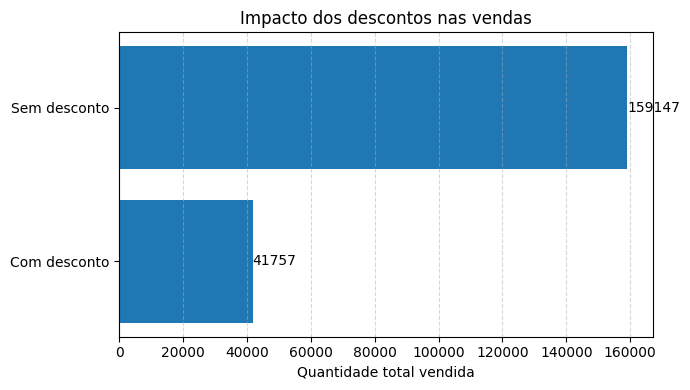

In [ ]:
comparacao = {
    "Com desconto": total_com_desconto,
    "Sem desconto": total_sem_desconto
}

plt.figure(figsize=(7,4))

barras = plt.barh(
    comparacao.keys(),
    comparacao.values()
)

plt.title("Impacto dos descontos nas vendas")

plt.xlabel("Quantidade total vendida")

plt.grid(axis='x', linestyle='--', alpha=0.5)

for barra in barras:
    largura = barra.get_width()

    plt.text(
        largura + 50,
        barra.get_y() + barra.get_height()/2,
        f"{largura:.0f}",
        va='center'
    )

plt.tight_layout()

plt.show()

In [ ]:
# vendas com promoção
com_desconto = df[df["Desconto"] > 0]

# vendas sem promoção
sem_desconto = df[df["Desconto"] == 0]

# média das vendas
media_com_desconto = com_desconto["Quantidade"].mean()
media_sem_desconto = sem_desconto["Quantidade"].mean()

print("Média de vendas COM desconto:")
print(media_com_desconto)

print("\nMédia de vendas SEM desconto:")
print(media_sem_desconto)

Média de vendas COM desconto:
9.989712918660286

Média de vendas SEM desconto:
10.012393834539163


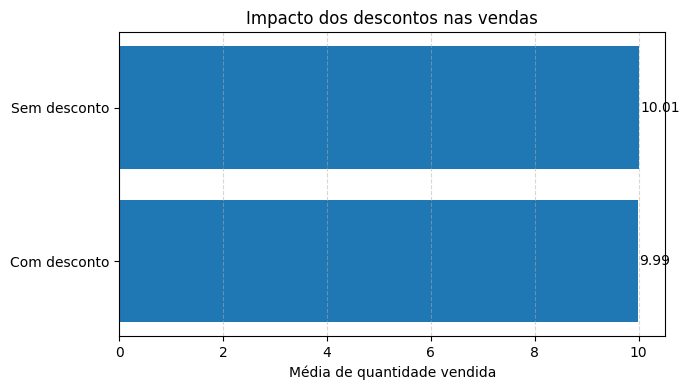

In [ ]:
comparacao = {
    "Com desconto": media_com_desconto,
    "Sem desconto": media_sem_desconto
}

plt.figure(figsize=(7,4))

barras = plt.barh(
    comparacao.keys(),
    comparacao.values()
)

plt.title("Impacto dos descontos nas vendas")

plt.xlabel("Média de quantidade vendida")

plt.grid(axis='x', linestyle='--', alpha=0.5)

# valores nas barras
for barra in barras:
    largura = barra.get_width()
    plt.text(
        largura + 0.02,
        barra.get_y() + barra.get_height()/2,
        f"{largura:.2f}",
        va='center'
    )

plt.tight_layout()

plt.show()

In [ ]:
produtos_promocao = com_desconto.groupby(
    "Produto"
)["Quantidade"].sum().sort_values(ascending=False).head(10)

print(produtos_promocao)

Produto
Frango             865
Talheres           846
Leite              842
Farinha            840
Maçãs              838
Azeite             821
Ração para cães    813
Papel higiênico    812
Cervejas           806
Salmão             797
Name: Quantidade, dtype: int64


## Comparação entre média de vendas e volume total vendido

Inicialmente foi realizada uma análise do volume total vendido, permitindo observar o impacto acumulado das promoções nas vendas gerais da empresa. 

Posteriormente, foi analisada a média de quantidade vendida entre produtos com e sem desconto. Os resultados mostraram diferenças relativamente pequenas entre os grupos.

A utilização das duas abordagens fornece uma visão mais completa sobre os efeitos das estratégias promocionais.